In [26]:
using Optics_in_the_length_gauge
using StaticArrays, Brillouin, Bravais

const I2 = @SMatrix [1 0; 0 1]
const σs = [[0 1; 1 0], [0 -im; im 0], [1 0; 0 -1]]

3-element Vector{Matrix{Complex{Int64}}}:
 [0 + 0im 1 + 0im; 1 + 0im 0 + 0im]
 [0 + 0im 0 - 1im; 0 + 1im 0 + 0im]
 [1 + 0im 0 + 0im; 0 + 0im -1 + 0im]

In [37]:
Weyl_point_hamiltonian(μ, t, k) = -μ*I2 .+ sum([t[i]*k[i]*I2 + k[i]*σs[i] for i in 1:3])
Weyl_point_dh(t, k, a::Symbol) = Weyl_point_dh(t, k, symtoind(a))
Weyl_point_dh(t, k, a::Int) = t[a]*I2 + σs[a]

 function symtoind(a::Symbol)
    if     a == :x
        1
    elseif a == :y
        2
    elseif a == :z
        3
    end
end

symtoind (generic function with 1 method)

In [39]:
t = [1,1,1]
k = [1,2,3]
μ = 0
Weyl_point_hamiltonian(μ, t,k)

2×2 SMatrix{2, 2, Complex{Int64}, 4} with indices SOneTo(2)×SOneTo(2):
 9+0im  1-2im
 1+2im  3+0im

In [29]:
Weyl_point_dh(t,k, :y)

2×2 SMatrix{2, 2, Complex{Int64}, 4} with indices SOneTo(2)×SOneTo(2):
 1+0im  0-1im
 0+1im  1+0im

### Wrapper

## Bands

In [77]:
using CairoMakie, BZpaths, LinearAlgebra

function bands(i, μ, ts, q)
    ϵs, ψs = eigen(Weyl_point_hamiltonian(μ,ts,q))   
    return ϵs[i]
end

function bs(μ; ts= [1,1,1], a = 1)
    # Rs = [[a, 0, 0], [0,a,0], [0, 0.0, a]]
    # sgnum = 32 # cube in 3d
    c = a 
    sgnum = 144 # 
    Rs = [[a, 0, 0], [-a/2, sqrt(3)*a/2, 0], [0, 0, c]]
    # Rs = [[a/2, sqrt(3)*a/2, 0], [-a/2, sqrt(3)*a/2, 0], [0, 0, c]]
    N = 200    #kpoints
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]", title = "t1 = $(ts[1]) eV, t2 = $(ts[2]) eV, t3 = $(ts[3]) eV")
    for i in 1:2
        dispersion(q) = bands(i, μ, ts, q)
        BZpaths.plot_observable_in_kpath!(ax, dispersion, Rs, sgnum, N)#, high_sym_line high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A] )
    end
    fig
end

bs (generic function with 3 methods)

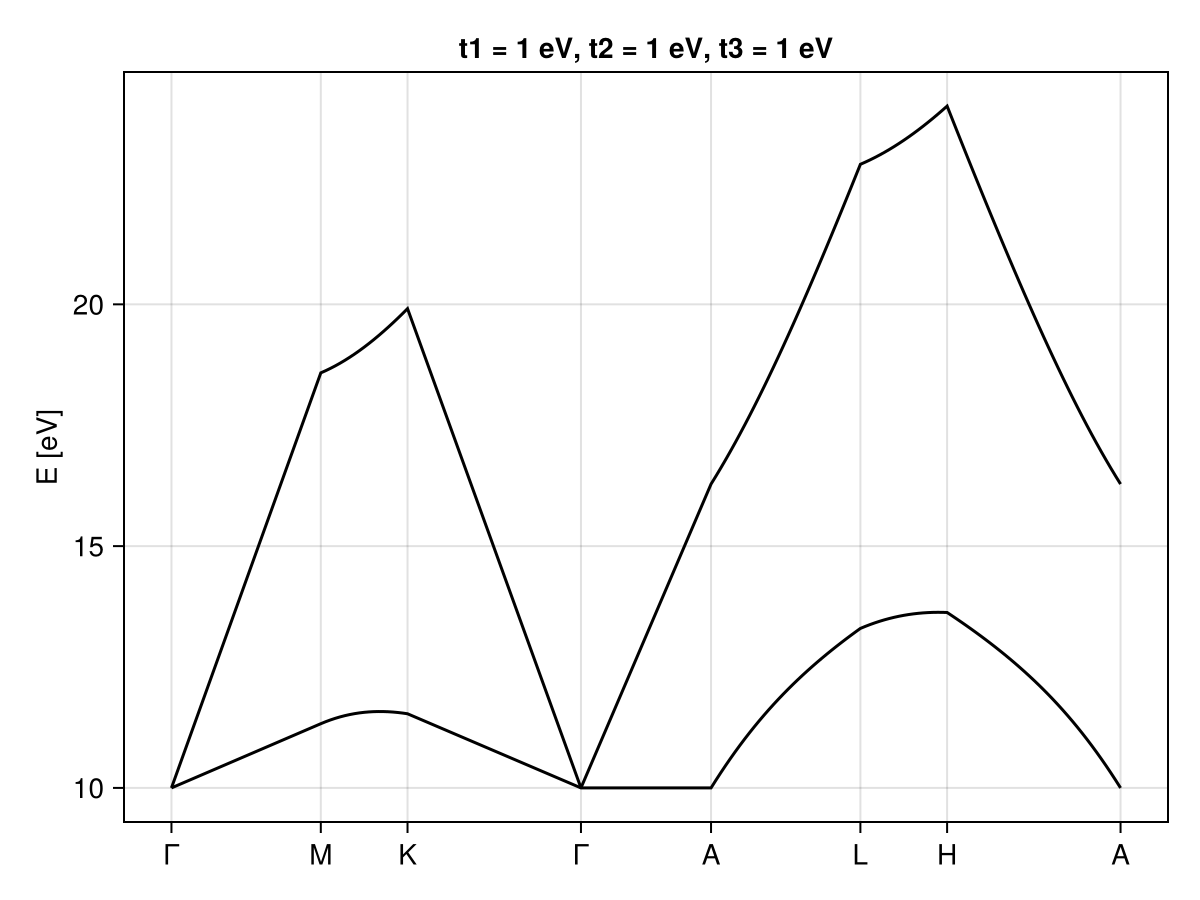

In [120]:
bs(-10, ts=[1,1,1])

## Calculation

In [82]:
"""
structure wrapper botbounds and topbounds in [-0.5,0.5]
"""
function sigma_abc_weyl(μ; ts = [0.0,0.0,0.0], dirj=:x, dirE=:y, dirB=:z, T = 1, τ = 200, evals = 100, 
        omega_MM_switch = true, PS_switch = true, QM_switch = true, fermi_surface = false,
        which_mm = :orbital, epsilon = 1e-5, integration_method = :hcubature,
        botbounds = [-0.5,-0.5,-0.5], topbounds = [0.5,0.5,0.5])
    a = 1.0 # Å
    c = a 
    sgnum = 144 # 
    Rs = [[a, 0, 0], [-a/2, sqrt(3)*a/2, 0], [0, 0, c]]
    Gs = dualbasis(Rs)
    
    h(q) = Weyl_point_hamiltonian(μ, t,q) #in 
    dhx(q) = Weyl_point_dh(t,q, :x)
    dhy(q) = Weyl_point_dh(t,q, :y)
    dhz(q) = Weyl_point_dh(t,q, :z)
    dh(q) = [dhx(q), dhy(q), dhz(q)]
    didjh(q,i,j) = 0 .* h([0,0,0])
    ddh(q) = [[didjh(q,:x,:x), didjh(q,:x,:y), didjh(q,:x,:z)],
            [didjh(q,:y,:x), didjh(q,:y,:y), didjh(q,:y,:z)], 
            [didjh(q,:z,:x), didjh(q,:z,:y), didjh(q,:z,:z)]]

    # integral presets

    
    computation = Transport_computation_3d_presets(botbounds,topbounds, evals, integration_method)
    return Quantum_correction_σijk_antisym(a, dirj, dirE, dirB, h, dh, ddh, Gs, τ, T, computation,
         which_mm, omega_MM_switch, PS_switch, QM_switch, fermi_surface, epsilon)
end

sigma_abc_weyl

In [115]:
sigma_abc_weyl()

Quantum_correction_σijk_antisym{SVector{3, Vector{Float64}}, var"#h#62", var"#dh#66"{var"#dhz#65", var"#dhy#64", var"#dhx#63"}, var"#ddh#68"{var"#didjh#67"{var"#h#62"}}}
  a0: Float64 1.0
  dirJ: Symbol x
  dirE: Symbol y
  dirB: Symbol z
  h: h (function of type var"#h#62")
  nabla_h: dh (function of type var"#dh#66"{var"#dhz#65", var"#dhy#64", var"#dhx#63"})
  nabla_nabla_h: ddh (function of type var"#ddh#68"{var"#didjh#67"{var"#h#62"}})
  gs: SVector{3, Vector{Float64}}
  τ: Float64 200.0
  T: Float64 1.0
  computation: Transport_computation_3d_presets
  which_mm: Symbol orbital
  Ω_MM_switch: Bool true
  PS_switch: Bool true
  QM_switch: Bool true
  fermi_surface: Bool false
  epsilon: Float64 1.0e-5


In [114]:
quantum_contribution(sigma_abc_weyl(0, evals = 1000, epsilon =1e-5, omega_MM_switch = false, QM_switch = false))

Adaptive integration


-0.002729293521850561

In [99]:
μlist = collect(range(-1,1,length = 11))

s = [quantum_contribution(sigma_abc_weyl(μ, evals = 1000, epsilon =)) for μ in μlist]

Adaptive integration
Adaptive integration
Adaptive integration
Adaptive integration
Adaptive integration
Adaptive integration
Adaptive integration
Adaptive integration
Adaptive integration
Adaptive integration
Adaptive integration


11-element Vector{Float64}:
  0.013150091881113192
  0.0010772467267016626
 -0.004599630913847861
  0.009042075067206357
 -0.009338474648562481
  0.0078734208435391
  0.009338215216042188
 -0.009042370074125767
  0.0045994640262419844
 -0.001077374574966477
 -0.013150822153916513

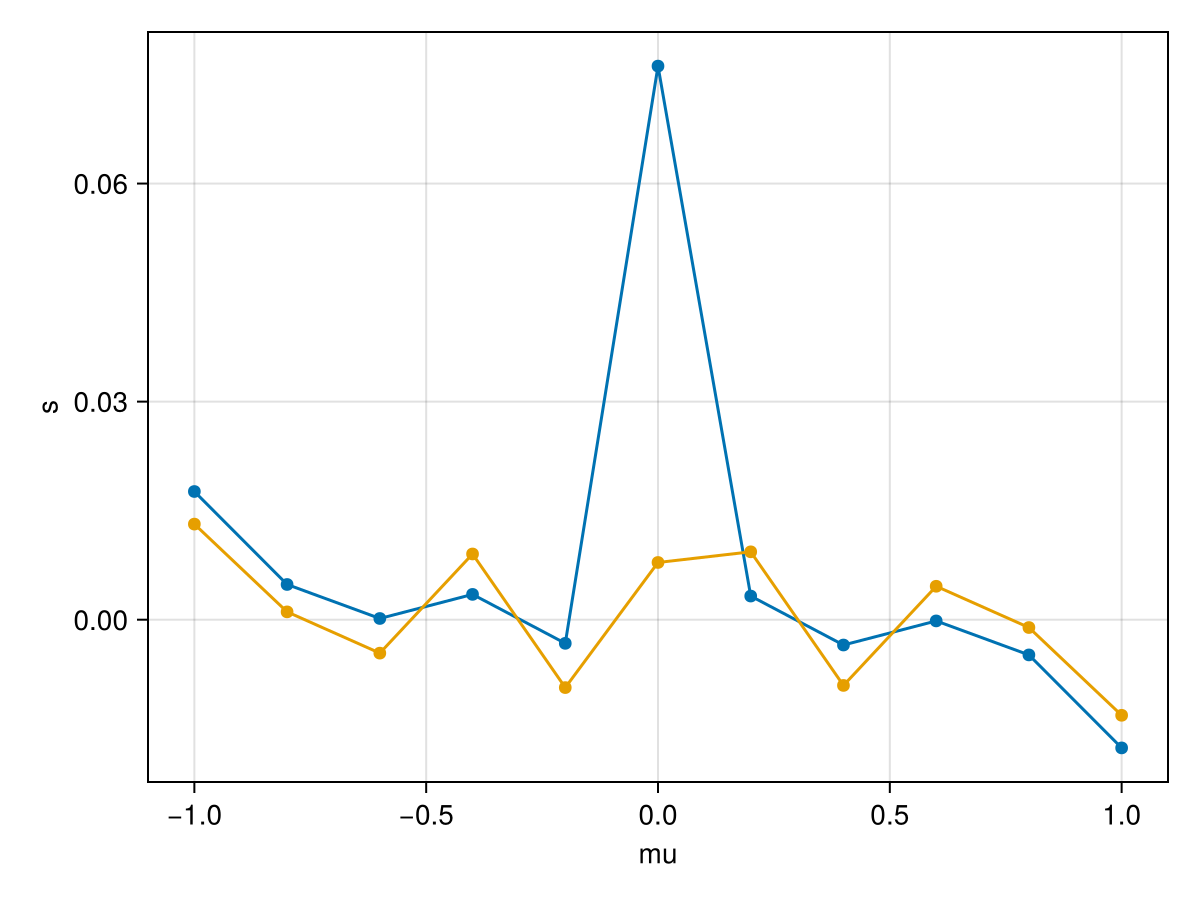

In [100]:
# fig = Figure(); ax = Axis(fig[1,1], xlabel = "mu", ylabel = "s")
lines!(ax, μlist, s)
scatter!(ax,μlist, s)
fig